In [1]:
import numpy as np
import matplotlib.pyplot as plt
from polynomial_optimization import run_poly_optimization, plot_piecewise_polynomials, plot_derivatives
from polynomial_optimization_clean import plot_xyz



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       81
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      108

Total number of variables............................:       24
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       14
Total number of inequality c

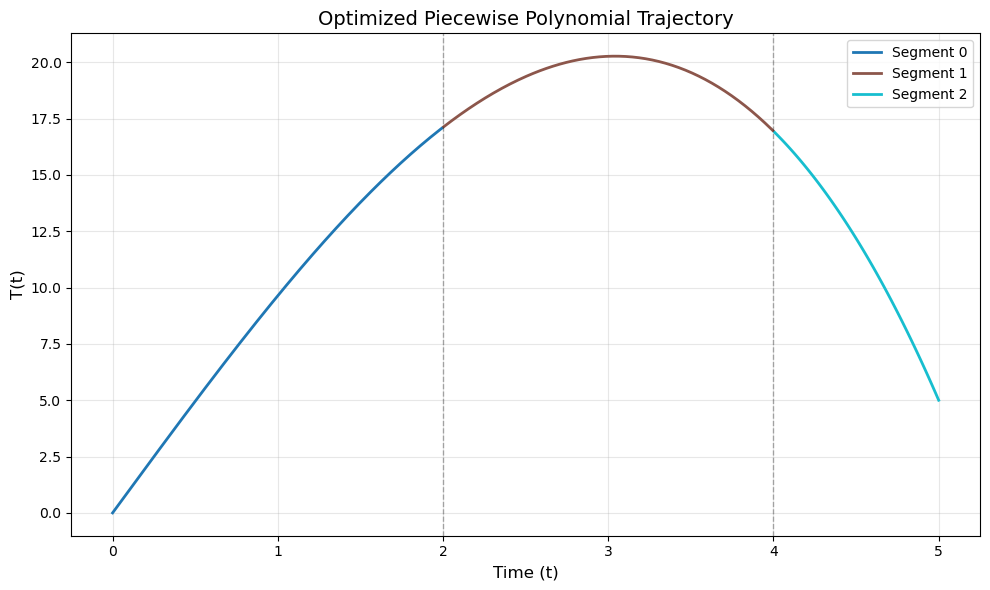

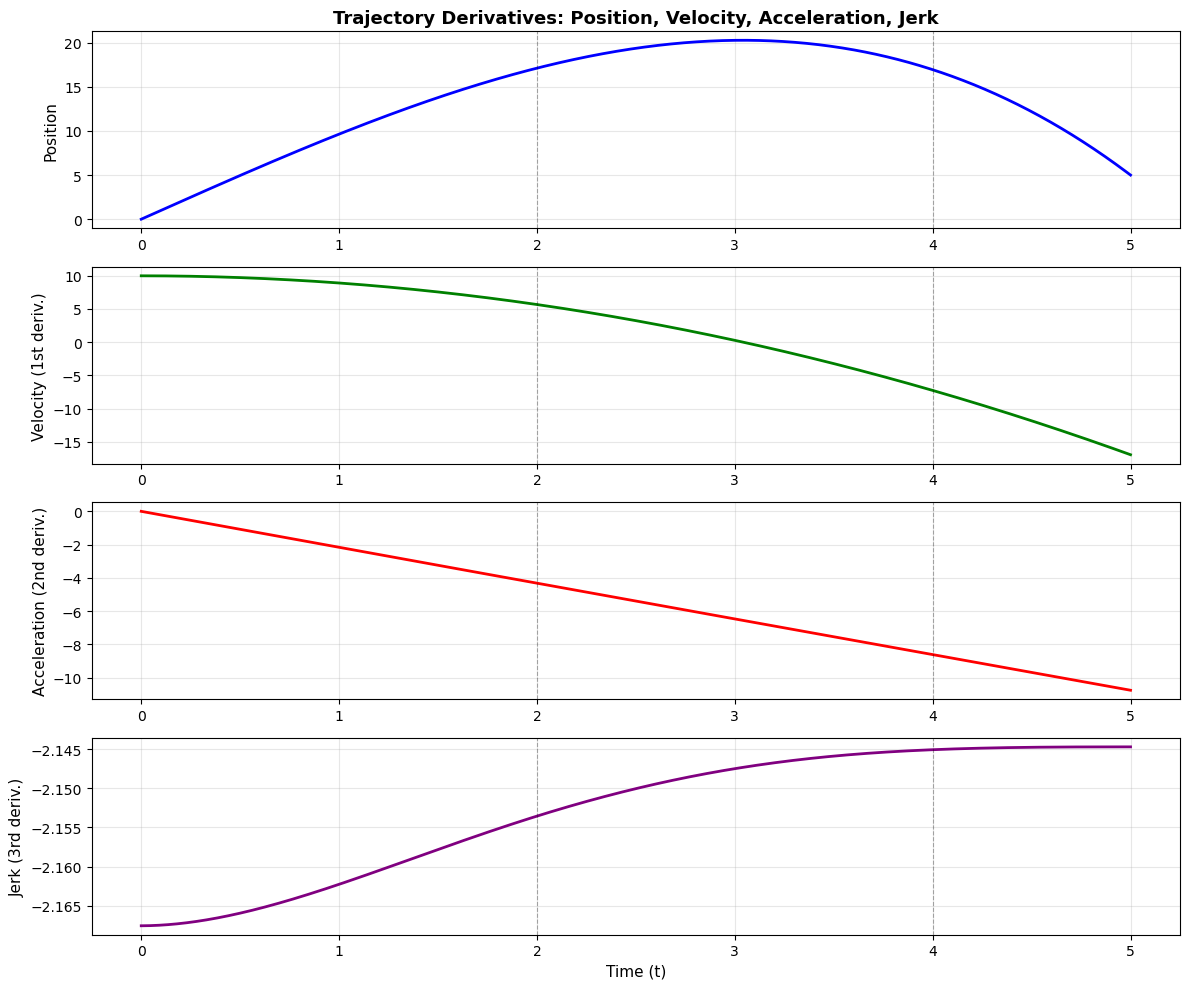

In [2]:
R = 3
boundary_positions = [[0, None, None, 5]]      # Position: start=0, end=
boundary_velocities = [[10, None, None, None]]       # Velocity: start=0, others free
boundary_accelerations = [[0, None, None, None]]    # Acceleration: start=0
boundary_jerk = [[None, None, None, None]]             # Jerk: start=0
boundary_snap = [[None, None, None, None]]             # Snap: start=0
boundary_crackle = [[None, None, None, None]]             # Snap: start=0
boundary_pop = [[None, None, None, None]]             # Snap: start=0
boundary_lock = [[None, None, None, None]]             # Snap: start=0

boundary_conditions = [
    boundary_positions,
    boundary_velocities,
    boundary_accelerations,
    boundary_jerk,
    boundary_snap,
    boundary_crackle,
    boundary_pop,
    boundary_lock
]

# Define acceleration discontinuities (jumps in 2nd derivative)
continuity_changes = None
tau = [2,2,1]  # Segment durations

# Solve optimization problem
outputs = run_poly_optimization(
    order=7,
    tau=tau,
    segments=3,
    weights=[0.1, 0.1, 0.1, 0.1, 1000, 0.1, 0.1, 0.1],  # Minimize snap (4th derivative)
    boundary_conditions=boundary_conditions,
    continuity=continuity_changes
)

# Plot results

fig1, ax1 = plot_piecewise_polynomials(
    outputs['polys'],
    tau,
    title="Optimized Piecewise Polynomial Trajectory"
)
plt.tight_layout()
plt.show()

fig2, axes2 = plot_derivatives(
    outputs['polys'],
    tau,
    title="Trajectory Derivatives: Position, Velocity, Acceleration, Jerk"
)
plt.show()


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       89
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       63

Total number of variables............................:       24
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       17
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 2.00e+01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

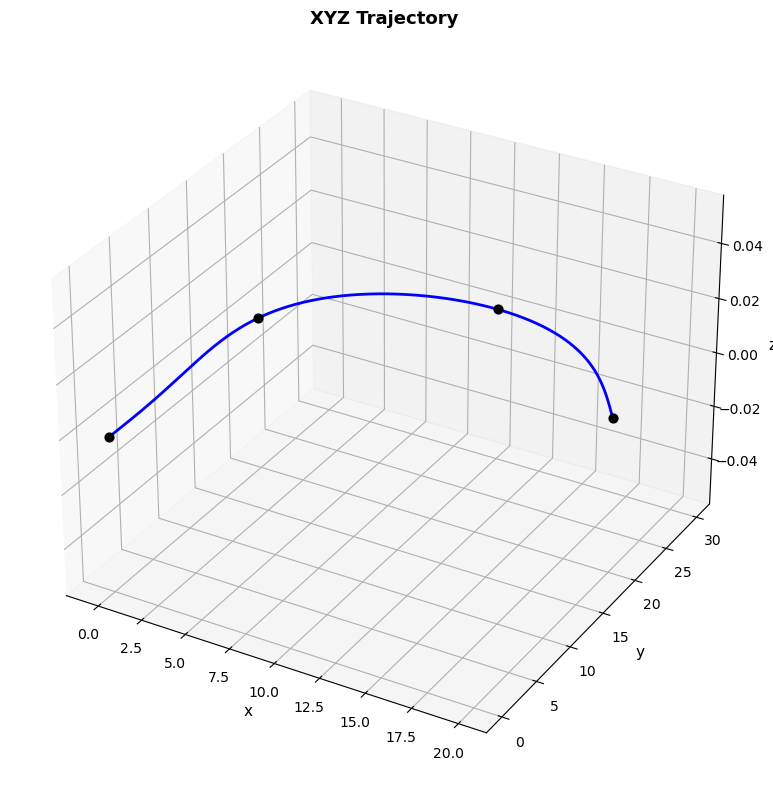

In [3]:
# X boundary conditions
# V = 8
seg_distances = [20, 10 * np.pi * 2/4 *1.25, 10 * np.pi * 2/4 *1.25]  # Segment durations

for j in range(1):
    x_boundary_positions = [[0, 0, 10, 20]]
    x_boundary_velocities = [[0, None, None, None]]
    x_boundary_accelerations = [[0, None, None, 0]]
    x_boundary_jerk = [[None, None, None, None]]
    x_boundary_snap = [[None, None, None, None]]
    x_boundary_crackle = [[None, None, None, None]]
    x_boundary_pop = [[None, None, None, None]]
    x_boundary_lock = [[None, None, None, None]]
    x_boundary_conditions = [
        x_boundary_positions,
        x_boundary_velocities,
        x_boundary_accelerations,
        x_boundary_jerk,
        x_boundary_snap,
        x_boundary_crackle,
        x_boundary_pop,
        x_boundary_lock
    ]

    # Y boundary conditions
    y_boundary_positions = [[0, 20, 30, 20]]
    y_boundary_velocities = [[8, None, None, None]]
    y_boundary_accelerations = [[None, None, None, 0]]
    y_boundary_jerk = [[None, None, None, None]]
    y_boundary_snap = [[None, None, None, None]]
    y_boundary_crackle = [[None, None, None, None]]
    y_boundary_pop = [[None, None, None, None]]
    y_boundary_lock = [[None, None, None, None]]
    y_boundary_conditions = [
        y_boundary_positions,
        y_boundary_velocities,
        y_boundary_accelerations,
        y_boundary_jerk,
        y_boundary_snap,
        y_boundary_crackle,
        y_boundary_pop,
        y_boundary_lock
    ]

    # Z boundary conditions
    z_boundary_positions = [[0, None, None, 0]]
    z_boundary_velocities = [[None, None, None, None]]
    z_boundary_accelerations = [[None, None, None, None]]
    z_boundary_jerk = [[None, None, None, None]]
    z_boundary_snap = [[None, None, None, None]]
    z_boundary_crackle = [[None, None, None, None]]
    z_boundary_pop = [[None, None, None, None]]
    z_boundary_lock = [[None, None, None, None]]
    z_boundary_conditions = [
        z_boundary_positions,
        z_boundary_velocities,
        z_boundary_accelerations,
        z_boundary_jerk,
        z_boundary_snap,
        z_boundary_crackle,
        z_boundary_pop,
        z_boundary_lock
    ]



    # Define acceleration discontinuities (jumps in 2nd derivative)
    continuity_changes = None
    tau = [seg_distance/8 for seg_distance in seg_distances]

    # Solve optimization problem
    outputsx = run_poly_optimization(
        order=7,
        tau=tau,
        segments=3,
        weights=[0, 0, 10, 0.1, 1000, 0.1, 0.1, 0.1],  # Minimize snap (4th derivative)
        boundary_conditions=x_boundary_conditions,
        continuity=continuity_changes
    )

    outputsy = run_poly_optimization(
        order=7,
        tau=tau,
        segments=3,
        weights=[0, 0, 10, 0.1, 1000, 0.1, 0.1, 0.1],  # Minimize snap (4th derivative)
        boundary_conditions=y_boundary_conditions,
        continuity=continuity_changes
    )

    outputsz = run_poly_optimization(
        order=7,
        tau=tau,
        segments=3,
        weights=[0, 0, 10, 0.1, 1000, 0.1, 0.1, 0.1],  # Minimize snap (4th derivative)
        boundary_conditions=z_boundary_conditions,
        continuity=continuity_changes
    )

    fig, axes, x, y,z, vx , vy , vz, ax, ay, az, jx, jy , jz, t= plot_xyz(outputsx['polys'],outputsy['polys'],outputsz['polys'], tau)

    xyz = np.stack([x, y, z], axis=1)
    sample_distances = np.linalg.norm(np.diff(xyz, axis=0), axis=1)

    seg_boundaries = np.concatenate([[0], np.cumsum(tau)])
    seg_distances = []
    for t_start, t_end in zip(seg_boundaries[:-1], seg_boundaries[1:]):
        mask = (t[:-1] >= t_start) & (t[:-1] < t_end)
        seg_distances.append(sample_distances[mask].sum())

    for i, d in enumerate(seg_distances):
        print(f"Segment {i+1} ({tau[i]:.2f}s): {d:.3f} m")
    print(f"Total: {sum(seg_distances):.3f} m")

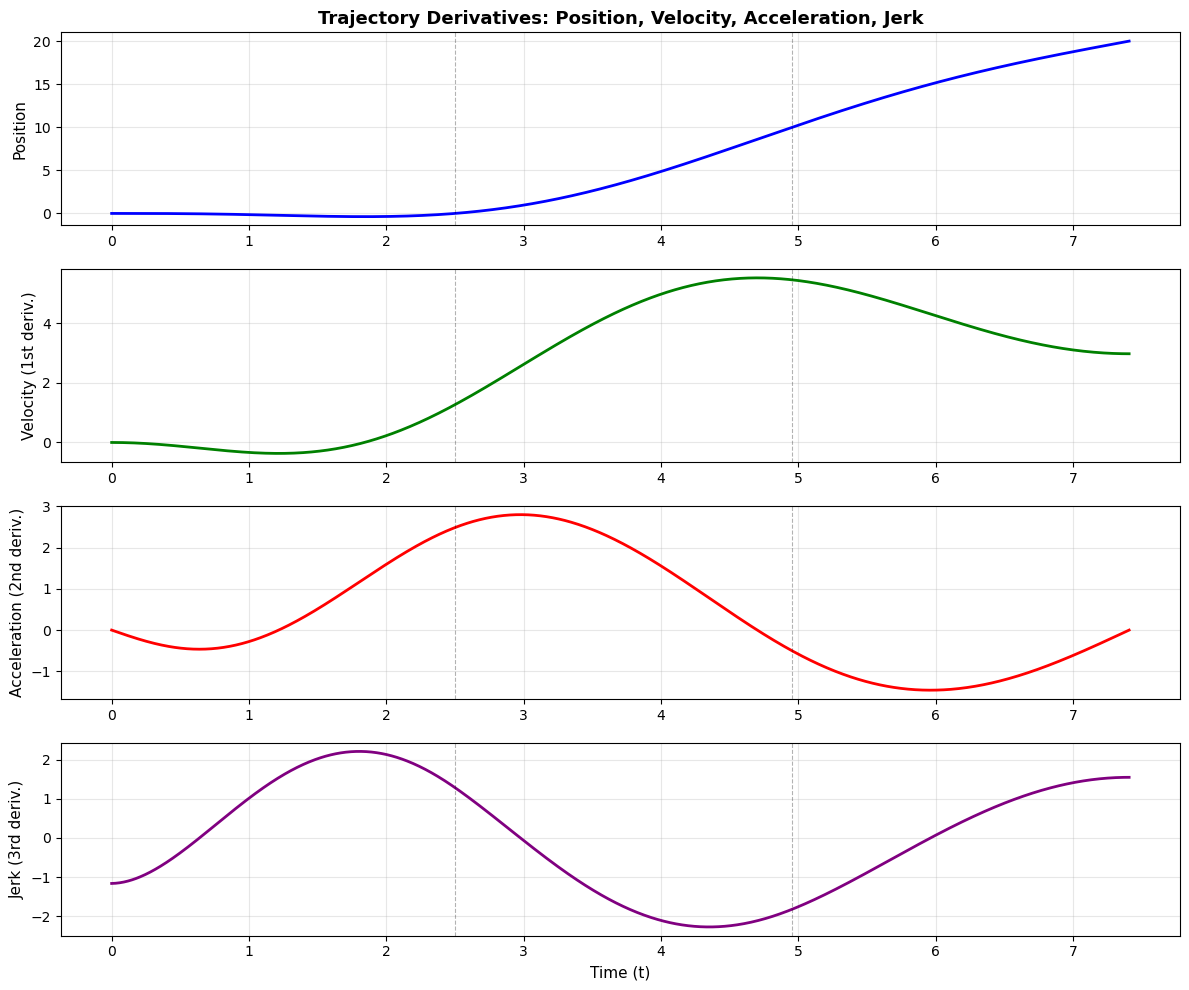

In [4]:
fig2, axes2 = plot_derivatives(
    outputsx['polys'],
    tau,
    title="Trajectory Derivatives: Position, Velocity, Acceleration, Jerk"
)
plt.show()

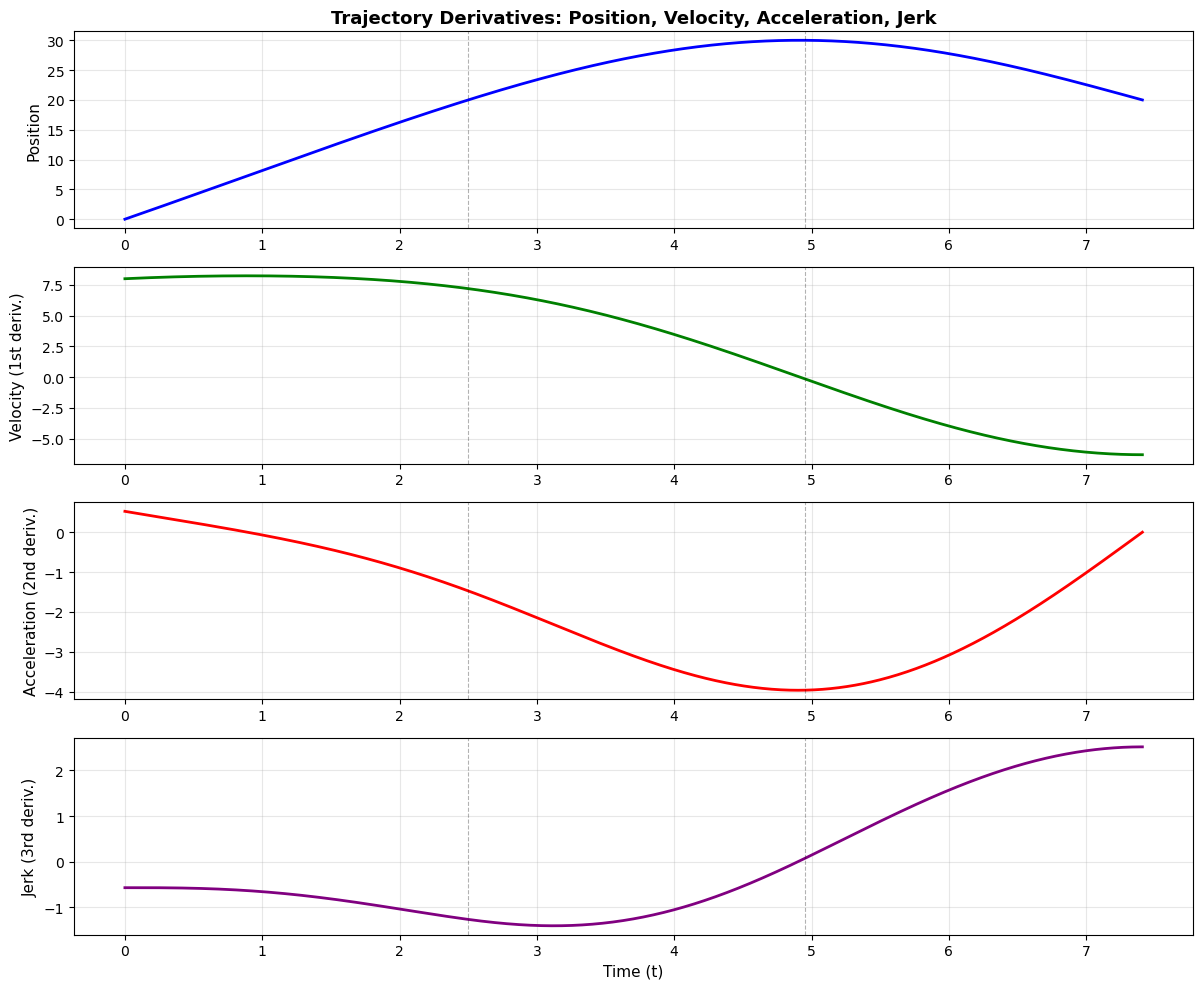

In [5]:
fig2, axes2 = plot_derivatives(
    outputsy['polys'],
    tau,
    title="Trajectory Derivatives: Position, Velocity, Acceleration, Jerk"
)
plt.show()

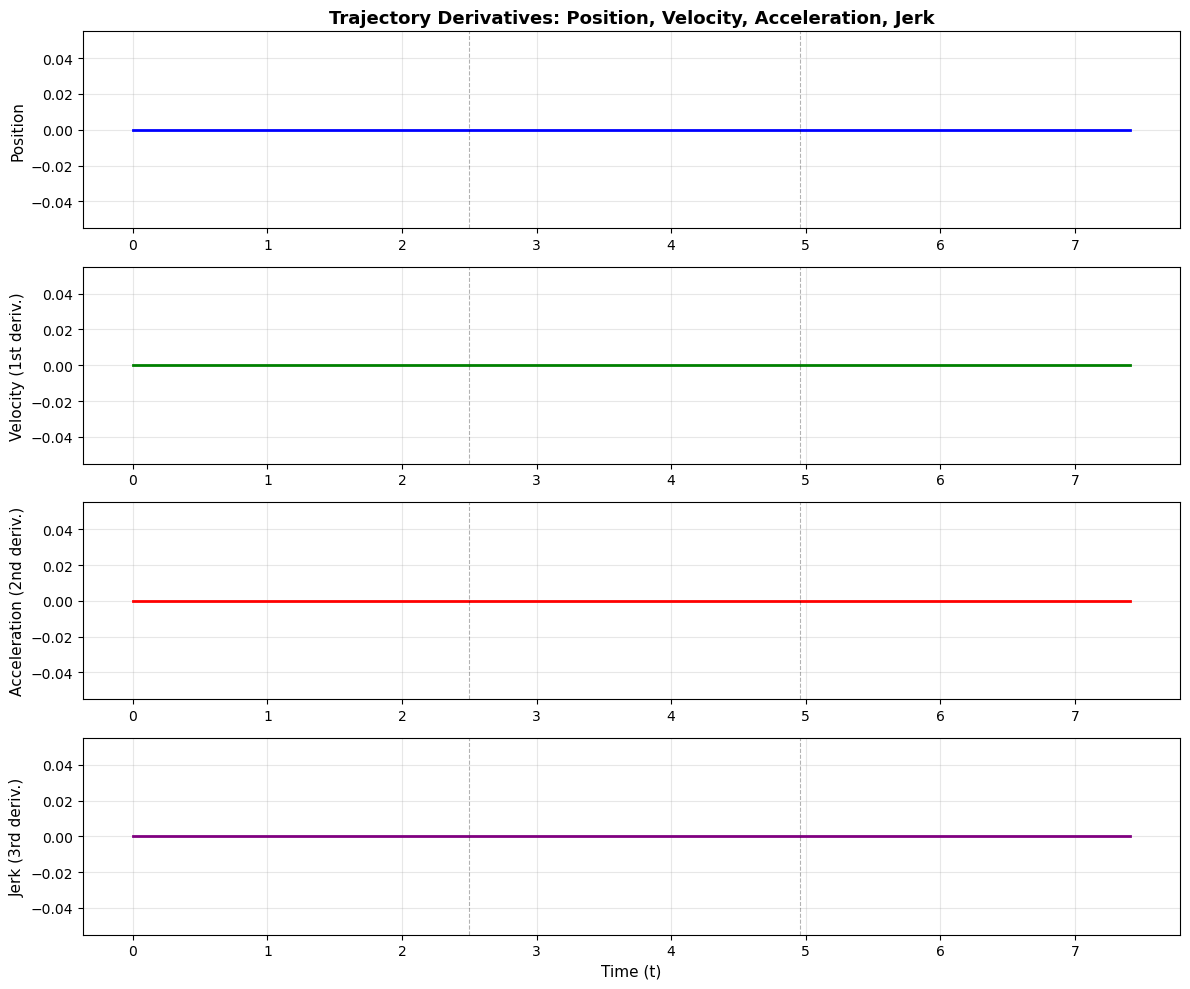

In [6]:
fig2, axes2 = plot_derivatives(
    outputsz['polys'],
    tau,
    title="Trajectory Derivatives: Position, Velocity, Acceleration, Jerk"
)
plt.show()

hi


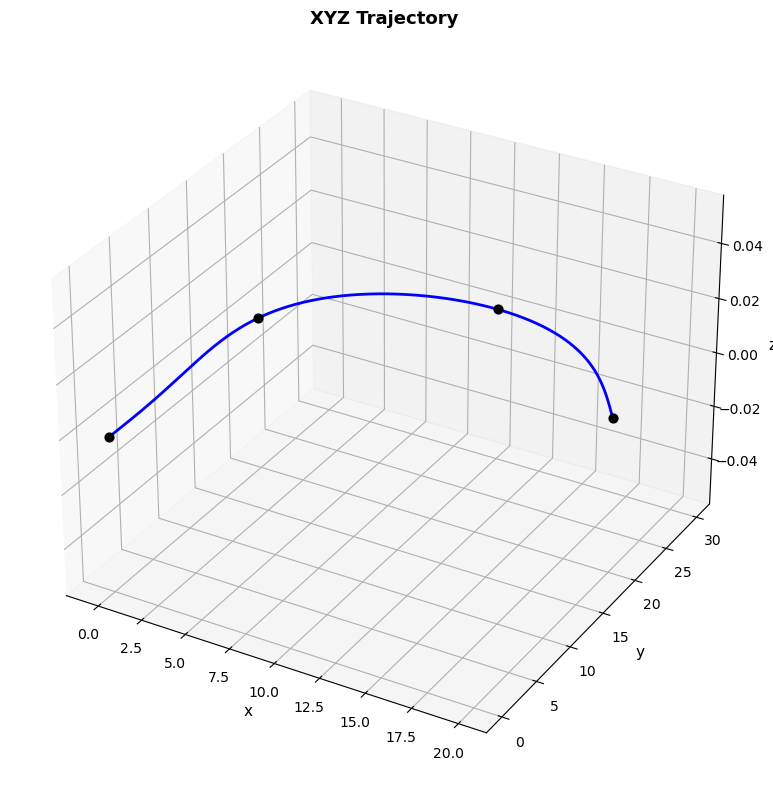

In [7]:
fig, ax3d, x, y, z, vx, vy, vz, accx, accy, accz, jerkx, jerky, jerkz, t = plot_xyz(outputsx['polys'], outputsy['polys'], outputsz['polys'], tau)

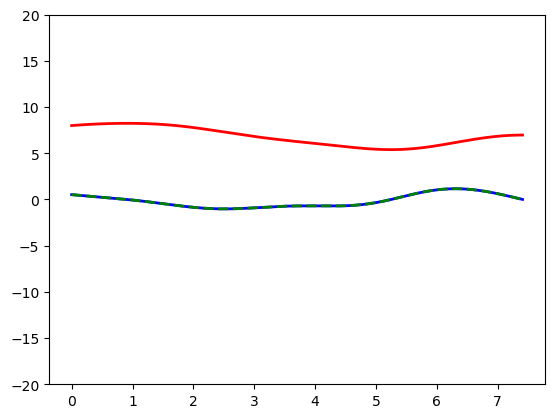

In [8]:
vs = np.sqrt(np.array(vx)**2 + np.array(vy)**2 + np.array(vz)**2)

a_vals = np.gradient(np.array(vs),t)
a_analytic = np.array(ax)*np.array(vx) + np.array(ay)*np.array(vy) + np.array(az)*np.array(vz)
a_analytic /= vs


plt.plot(t, vs, "r-", linewidth=2)
plt.ylim((-20, 20))
plt.plot(t, a_vals, "b-", linewidth=2)
plt.plot(t, a_analytic, "g--", linewidth=2)

In [9]:
# Models
thr_max = 0.3
m = 0.065
S = 0.055
rho = 1.225
g = 9.81
incidence = np.deg2rad(2)
CL0 = 0.5
CLa = 4.7
CD0 = 0.06
k = 0.09

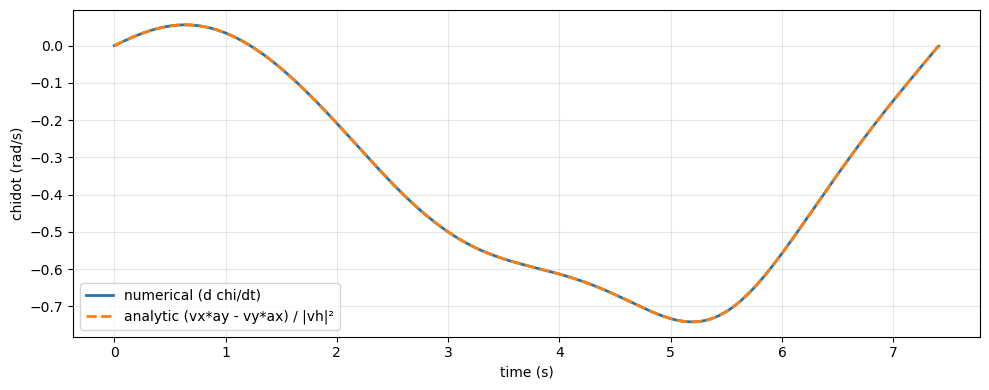

In [10]:
chi = np.arctan2(vy, vx)

chidot_num = np.gradient(chi, t)

vh2 = np.array(vx)**2 + np.array(vy)**2
chidot_analytic = (np.array(vx) * np.array(accy) - np.array(vy) * np.array(accx)) / vh2

plt.figure(figsize=(10, 4))
plt.plot(t, chidot_num, label="numerical (d chi/dt)", linewidth=2)
plt.plot(t, chidot_analytic, "--", label="analytic (vx*ay - vy*ax) / |vh|²", linewidth=2)
plt.xlabel("time (s)")
plt.ylabel("chidot (rad/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

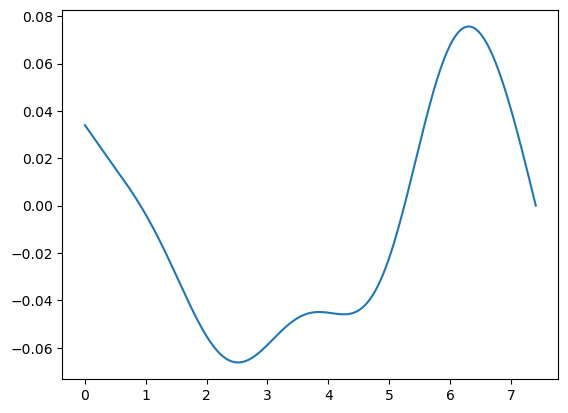

In [11]:
X_force = a_analytic * m
plt.plot(t, X_force)

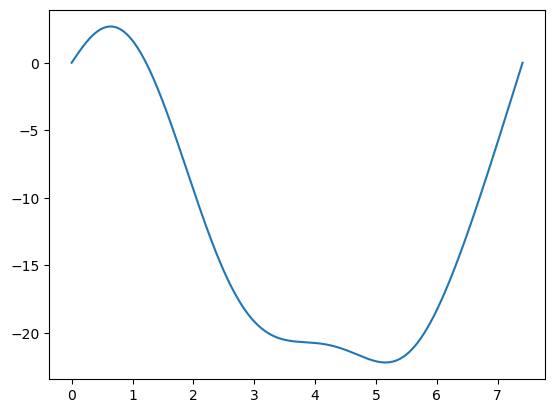

In [12]:
# mu

mu = np.arctan(vs * chidot_analytic / g)
plt.plot(t, np.rad2deg(mu))

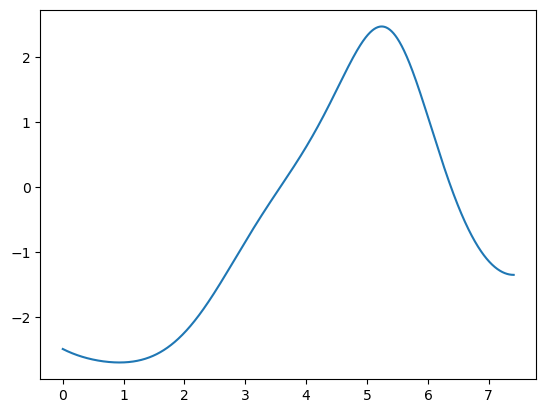

In [13]:
# alpha
alpha0 = ((m*g / np.cos(mu)) / (1/2 * rho * vs**2 * S) - CL0) / CLa
Cl = CLa * alpha0 + CL0
Cd = CD0 + k * Cl**2

T0 = (m * a_analytic + 1/2 * rho * vs**2 * S * Cd)/np.cos(alpha0)

plt.plot(t, np.rad2deg(alpha0))


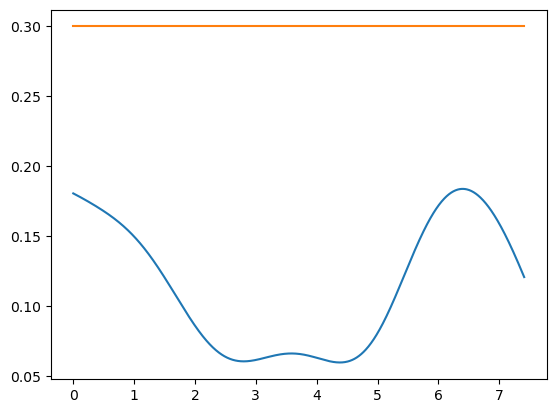

In [14]:
plt.plot(t, T0)
plt.plot([0, t[-1]], [thr_max, thr_max])

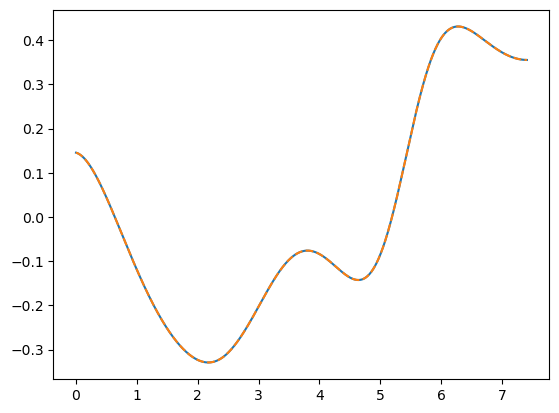

In [15]:
chidot_dot_analytic = (accx * accy + vx * jy - accx * accy - vy * jx) * (vx**2 + vy**2)- (vx * accy - vy * accx) * (2 * vx * accx + 2 * vy * accy)
chidot_dot_analytic = chidot_dot_analytic / (vx**2 + vy**2)**2

chidotdot_num = np.gradient(chidot_analytic, t)


plt.plot(t, chidot_dot_analytic)
plt.plot(t, chidotdot_num, "--")

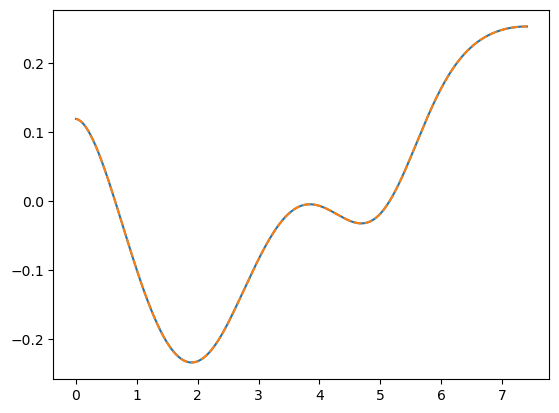

In [16]:
mu_dot_analytic = 1/((vs * chidot_analytic / g)**2 + 1) * (vs * chidot_dot_analytic / g + a_analytic * chidot_analytic / g)

mu_dot_grad = np.gradient(mu, t)

plt.plot(t, mu_dot_analytic)
plt.plot(t, mu_dot_grad, "--")

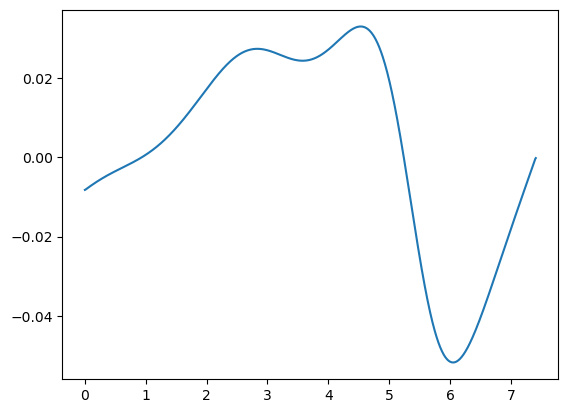

In [17]:
alpha_dot = np.gradient(alpha0, t)
plt.plot(t, alpha_dot)

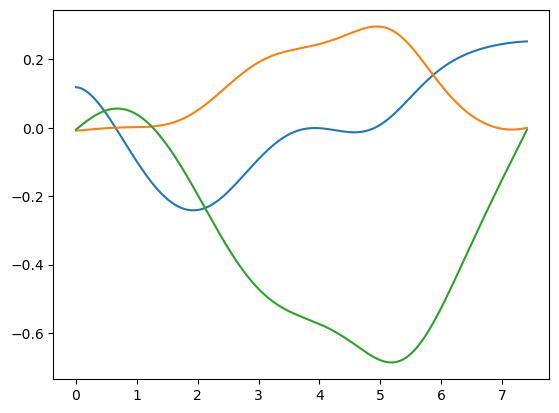

In [18]:
Z_force = -m*g * np.sin(mu) * np.tan(mu)
Y_force = m * g * np.sin(mu)


q = alpha_dot - Z_force/m/vs
r = Y_force * np.cos(alpha0) / m / vs + mu_dot_analytic * np.sin(alpha0)
p = mu_dot_analytic / np.cos(alpha0) - r * np.tan(alpha0)

plt.plot(t, p)
plt.plot(t, q)
plt.plot(t, r)

In [19]:
from polynomial_planner import plan_path

t, xcheck, ycheck, zcheck, chicheck, mucheck, gammacheck, alpha0check, betacheck, pcheck, qcheck, rcheck, T0check = plan_path(V, m, S, rho, g, CL0, CLa, CD0, k)

NameError: name 'V' is not defined

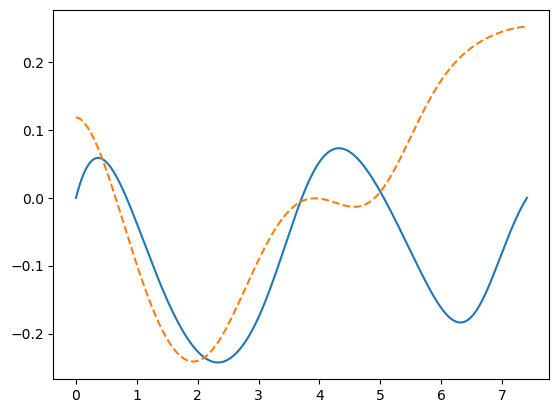

In [ ]:
plt.plot(t, pcheck)
plt.plot(t, p, '--')

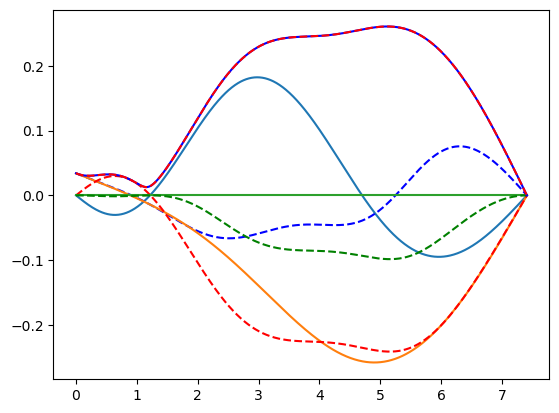

In [20]:
plt.plot(t, accx*m)
plt.plot(t, X_force, "b--")
plt.plot(t, accy*m)
plt.plot(t, Y_force, "r--")
plt.plot(t, accz*m)
plt.plot(t, Z_force, "g--")

plt.plot(t, np.sqrt(X_force**2 + Y_force**2 + Z_force**2), "b")
plt.plot(t, m*np.sqrt(accx**2 + accy**2 + accz**2), "r--")


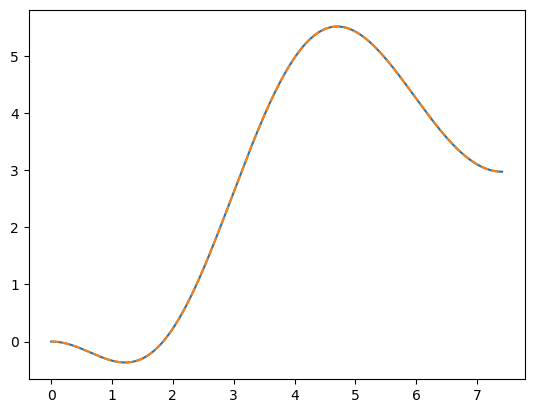

In [21]:
plt.plot(t, vx)
plt.plot(t, vs * np.cos(chi) * np.cos(0), '--')

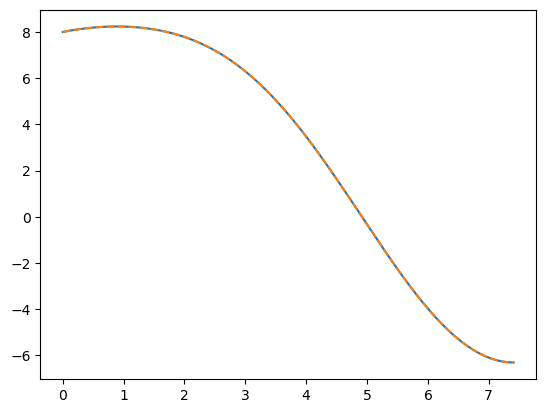

In [23]:
plt.plot(t, vy)
plt.plot(t, vs * np.sin(chi) * np.cos(0), '--')

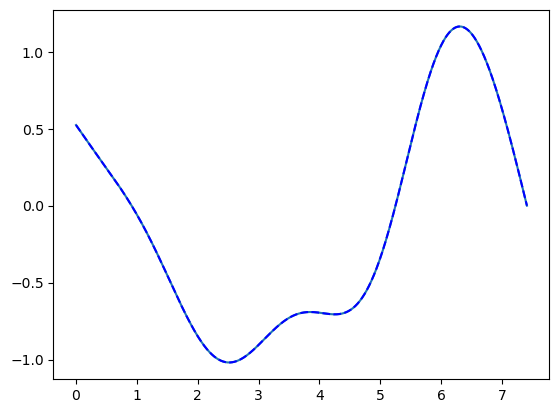

In [24]:
plt.plot(t, a_analytic)
plt.plot(t, X_force/m, "b--")

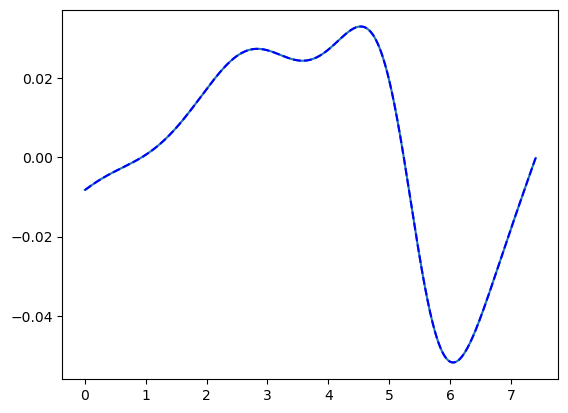

In [25]:
plt.plot(t, alpha_dot)
plt.plot(t, q + Z_force /m /vs, 'b--')

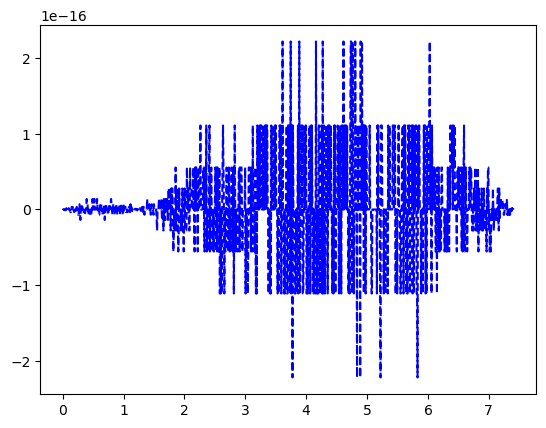

In [26]:
plt.plot(t, p * np.sin(alpha0) - r * np.cos(alpha0) + Y_force/m/vs, 'b--')

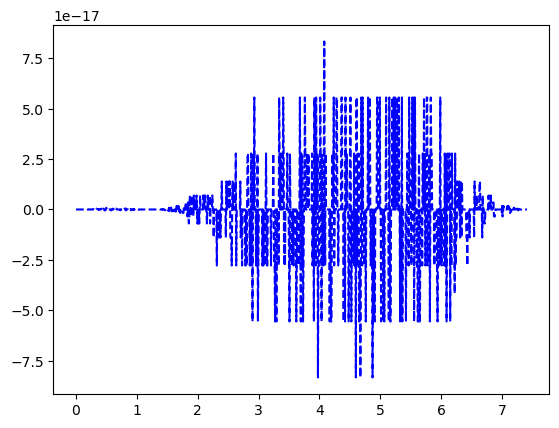

In [30]:
plt.plot(t, -Y_force * np.sin(mu) / m /vs - Z_force * np.cos(mu) / m / vs, 'b--')

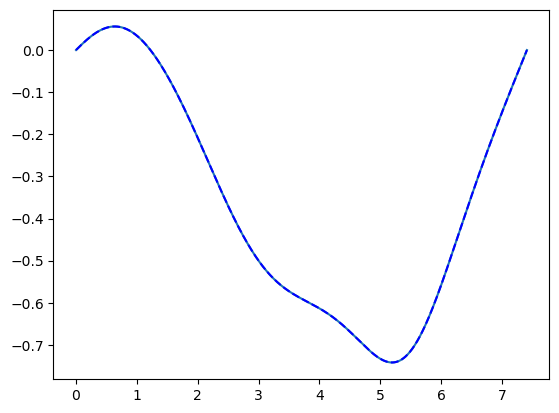

In [32]:
plt.plot(t, chidot_analytic)
plt.plot(t,Y_force * np.cos(mu) / m / vs - Z_force * np.sin(mu) / m / vs, 'b--')

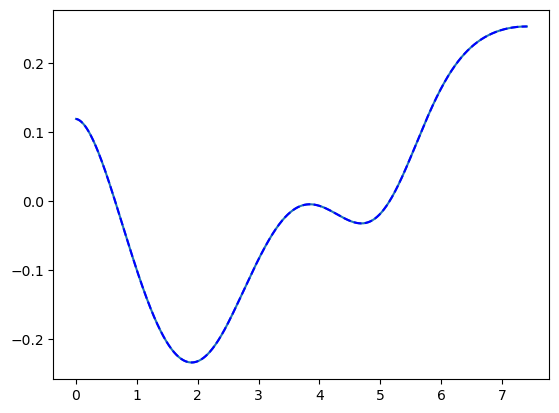

In [33]:
plt.plot(t, mu_dot_analytic)
plt.plot(t, p * np.cos(alpha0) + r * np.sin(alpha0), 'b--')

In [ ]:
def R(angle, axis):
    c, s = np.cos(angle), np.sin(angle)
    if axis == 1:  # x
        return np.array([[1,0,0],[0,c,-s],[0,s,c]])
    elif axis == 2:  # y
        return np.array([[c,0,s],[0,1,0],[-s,0,c]])
    elif axis == 3:  # z
        return np.array([[c,-s,0],[s,c,0],[0,0,1]])
    else:
        raise ValueError("Axis must be 1 (x), 2 (y), or 3 (z)")



ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (3, 3) + inhomogeneous part.

In [64]:
from cyecca.lie import group_se23, SO3Dcm
SE23DCM = group_se23.SE23LieGroup(SO3 = SO3Dcm)
import casadi as ca

def convert_x_to_group(x_vec):
    x = x_vec[0]
    y = x_vec[1]
    z = x_vec[2]
    V = x_vec[3]
    alpha = x_vec[4]
    beta = x_vec[5]
    chi = x_vec[6]
    gamma = x_vec[7]
    mu = x_vec[8]

    Rbw = R(alpha, axis=2) @ R(-beta, axis=3) @ R(mu, axis=1) @ R(-gamma, axis=2) @ R(-chi, axis=3)
        
        # Takes stuff from body to world frame
    Rwb = Rbw.T

    v_body = R(alpha, axis=2) @ R(-beta, axis=3) @np.array([V, 0, 0])
    v_world = Rwb @ v_body    


        
    X = np.eye(5)
    X[:3, :3] = Rwb
    X[:3, 3] = v_world
    X[:3, 4] = np.array([x, y, z])


    X_ca = SE23DCM.elem(ca.vertcat(x, y, z, v_world, Rwb.flatten()))

    return X_ca

In [65]:
X, X_ca = convert_x_to_group([1,2,3,5,0,0,np.deg2rad(90),np.deg2rad(90),np.deg2rad(90)])
np.round(X, 3)

np.round(np.array(ca.DM(X_ca.to_Matrix())) - X, 3)

TypeError: cannot unpack non-iterable SE23LieGroupElement object

In [ ]:
X_bar = convert_x_to_group([1,2,3,5,0,0,np.deg2rad(90),np.deg2rad(90),np.deg2rad(90)])
X_group = convert_x_to_group([4,2,3,5,0,0,np.deg2rad(70),np.deg2rad(80),np.deg2rad(90)])

omega_tilde_prev = np.array([0.1, 0.2, 0.3])
T_tilde_prev = 0.05
m = 0.065
Kp = np.diag([1, 1, 1])
Kr = np.diag([1, 1, 1])
omega_bar = np.array([0.01, 0.02, 0.03])
Kv = np.diag([1, 1, 1])

print(X_bar)
print(X_group)

eta_i = X_bar.inverse()*X_group
xi = eta_i.log()  # log map to Lie algebra
xi_param = xi.param

Jlinv = xi.left_jacobian_inv()

c1 = Jlinv[:3,:3]
c2 = Jlinv[:3,3:6]
c3 = Jlinv[:3,6:9]
c4 = Jlinv[3:6,6:9]


xi_p = xi_param[0:3]  # position error, expressed in reference frame
xi_v = xi_param[3:6]  # velocity error, expressed in reference frame
xi_R = xi_param[6:9]  # attitude error (so(3) coordinates), rotates from body (a) to reference (b) v_b = R_ba v_a

R_ba = eta_i.R
R_ab = R_ba.inverse()

xi_v_des_dot = ca.vertcat(
    0, 0, 0
)  # desired acceleration feedforward (simplified)
xi_R_des_dot = ca.vertcat(
    0, 0, 0
)  # desired attitude feedforward (simplified)

xi_v_des = -c3 @ omega_tilde_prev - (c2/m) @ T_tilde_prev - Kp @ xi_p
e_v = xi_v - xi_v_des

a_des = (  # desired acceleration, expressed in reference frame
                - Kv @ e_v  # velocity feedback, expressed in reference frame
                - xi_v_des_dot  # desired acceleration feedforward, expressed in reference frame
                - ca.cross(
                    w_b, xi_v_des
                )
                - c3 @ omega_tilde_prev
            )

T_tilde = ca.dot(a_des, ca.vertcat(1,0,0))/(c1/m)[0,0] 


Tau = -T_bar/m
xi_rd_x = 0
xi_rd_y = (ca.dot(a_des, ca.vertcat(0,0,1)) - T_tilde * (c1/m)[2,0]) / Tau
xi_rd_z = (ca.dot(a_des, ca.vertcat(0,1,0)) - T_tilde * (c1/m)[1,0]) / (-Tau)

xi_R_des = ca.vertcat(xi_rd_x, xi_rd_y, xi_rd_z)

e_R = xi_R - xi_R_des

omega_tilde = ca.inv(c1)@(ca.cross(omega_bar, xi_R) + xi_R_des_dot - Kr @ e_R)

T = T_bar + T_tilde
omega = omega_bar + omega_tilde

SE23LieGroup: SX(@1=3.7494e-33, @2=-1, [1, 2, 3, 1.8747e-32, 3.06162e-16, -5, @1, -1.22465e-16, @2, 6.12323e-17, @2, 1.22465e-16, @2, -6.12323e-17, @1])
SE23LieGroup: SX([4, 2, 3, 0.296956, 0.81588, -4.92404, 0.0593912, -0.336824, -0.939693, 0.163176, -0.925417, 0.34202, -0.984808, -0.173648, 1.06329e-17])


NameError: name 'c1_inv' is not defined

In [ ]:
eta = X_b.inverse() * X_a  # X_b^{-1} * X_a = X_ba
xi = eta.log().param  # log map to Lie algebra
xi_p = xi[0:3]  # position error, expressed in reference frame
xi_v = xi[3:6]  # velocity error, expressed in reference frame
xi_R = xi[
    6:9
]  # attitude error (so(3) coordinates), rotates from body (a) to reference (b) v_b = R_ba v_a

R_ba = eta.R
R_ab = R_ba.inverse()

xi_v_des_dot = ca.vertcat(
    0, 0, 0
)  # desired acceleration feedforward (simplified)
xi_R_des_dot = ca.vertcat(
    0, 0, 0
)  # desired attitude feedforward (simplified)

            # position loop
            xi_v_des = -Kp @ xi_p  # desired velocity (virtual control input)

            # saturate desired velocity to reasonable values
            xi_v_des = self.saturate(
                xi_v_des, 100 * ca.vertcat(-1, -1, -1), 100 * ca.vertcat(1, 1, 1)
            )

            e_v = xi_v - xi_v_des  # velocity error

            a_des = (  # desired acceleration, expressed in reference frame
                - Kv @ e_v  # velocity feedback, expressed in reference frame
                - xi_v_des_dot  # desired acceleration feedforward, expressed in reference frame
                - ca.cross(
                    w_b, xi_v_des
                )
            )

            # saturate desired acceleration to max available thrust
            a_des_norm = ca.norm_2(a_des)
            a_des_ = ca.if_else(
                a_des_norm > thrust_max / m, a_des / a_des_norm * thrust_max / m, a_des
            )

            # thrust feedback term
            e_T = ca.dot(a_des, e1)

            # desired attitude
            xi_R_des = ca.vertcat(0, -ca.dot(a_des / T_b, e3), ca.dot(a_des / T_b, e2))

            # saturate desired attitude to reasonable values
            xi_R_des = self.saturate(
                xi_R_des, 1.0 * ca.vertcat(-1, -1, -1), 1.0 * ca.vertcat(1, 1, 1)
            )

            # handle no thrust case (we have no control authority then)
            # xi_R_des = ca.if_else(t < t_burn, xi_R_des, ca.vertcat(0, 0, 0))

            # attitude error
            e_R = xi_R - xi_R_des

            # desired angular velocity
            # Desired angular velocity includes reference orbital spin about z
            w_des = ca.cross(w_b, xi_R_des) + xi_R_des_dot - KR @ e_R

            # saturate desired angular velocity to reasonable values
            w_des = self.saturate(
                w_des, 1 * ca.vertcat(-1, -1, -1), 1 * ca.vertcat(1, 1, 1)
            )

            w_m = w_a + w_d  # measured angular velocity with disturbance
            e_w = w_m - w_des

            # applied torque
            M_a = M_b - Kw @ e_w

            # applied thrust
            T_a = ca.fmax(0, T_b + e_T)  # reference thrust magnitude

In [93]:
eta = X_bar.inverse() * X_group  # X_b^{-1} * X_a = X_ba
xi = eta.log()

Jlinv = xi.left_jacobian_inv()

c1 = Jlinv[:3,:3]/m
c2 = Jlinv[:3,3:6]
c3 = Jlinv[:3,6:9]
c4 = Jlinv[3:6,6:9]

print(c1)
print(c2)
print(c3)
print(c4)
np.round(np.array(ca.DM(xi.left_jacobian_inv())), 2)

c1[2,0]



[[15.2276, 2.67151, -0.311629], 
 [-2.68504, 15.1904, -1.31526], 
 [0.157008, 1.34252, 15.3451]]

[[00, 00, 00], 
 [00, 00, 00], 
 [00, 00, 00]]

[[0.173133, -1.49968, -0.0831066], 
 [1.49261, 0.176277, 0.0301982], 
 [0.173368, -0.0305695, 0.000538631]]

[[0.0253615, -0.173548, 0.382669], 
 [0.194616, 0.015381, -0.128673], 
 [-0.384269, 0.0821741, -0.00217278]]


SX(0.157008)